In [505]:
# !/usr/bin/env python3
import pandas as pd
import sys
import os

sys.path.append('../')
from src.data_loader import load_cement_data
from src.metric import print_metrics

# add warning filter to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [506]:
# load the cement data
df = load_cement_data()

In [507]:
display(df.head())

,date,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
1,2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
2,2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448
3,2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
4,2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448


In [508]:
df.describe()

,date,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
count,32880,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000
mean,2023-07-02 12:00:00.000000256,30.697158,23.720475,3066.682205,29.293009,3072.254739,5.008120,10.085887,317.533333
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,120.000000
25%,2022-10-01 18:00:00,12.830000,10.710000,1.280000,19.300000,1.270000,1.440000,3.340000,230.000000
50%,2023-07-02 12:00:00,33.455000,19.720000,50.710000,29.490000,50.660000,3.470000,9.990000,314.000000
75%,2024-04-01 06:00:00,47.612500,36.492500,3298.522500,39.750000,3312.062500,6.970000,16.700000,437.000000
max,2024-12-31 00:00:00,69.980000,69.970000,20646.180000,50.000000,20658.870000,50.000000,35.000000,487.000000
std,NaN,19.493713,16.846251,5586.029168,12.325600,5593.015910,4.997142,8.519946,112.813279


In [509]:
# filter the dataframe for a specific site_id
site_id = 'SITE_001'
site_df = df[df['site_id'] == site_id].copy()

In [510]:
# set the index to 'date' and sort the dataframe by date
site_df.set_index('date', inplace=True)
site_df = site_df.sort_index()

In [511]:
# create lag features for lag 1, 3, 7
site_df['lag_1'] = site_df['consumed_tonnes'].shift(1)
site_df['lag_3'] = site_df['consumed_tonnes'].shift(3)
site_df['lag_7'] = site_df['consumed_tonnes'].shift(7)

In [512]:
# rolling mean and standard deviation features
site_df['rolling_mean_3'] = site_df.groupby('site_id')['consumed_tonnes'].rolling(3).mean().reset_index(level=0, drop=True)
site_df['rolling_std_7'] = site_df.groupby('site_id')['consumed_tonnes'].rolling(7).std().reset_index(level=0, drop=True)

In [513]:
# create day of week, week of year, and month features
site_df['day_of_week'] = site_df.index.dayofweek
site_df['week_of_year'] = site_df.index.isocalendar().week
site_df['month'] = site_df.index.month

In [514]:
# check rain and temperature on planned pour days
site_df['rain_x_pour'] = site_df['rain_mm'] * site_df['planned_pour_tonnes']
site_df['temp_x_pour'] = site_df['avg_temp_c'] * site_df['planned_pour_tonnes']


In [515]:
site_df['behavior_encoded'] = site_df['behavior'].astype('category').cat.codes
site_df['cement_type_encoded'] = site_df['cement_type'].astype('category').cat.codes

In [516]:
# inventory features
site_df['inventory_gap'] = site_df['opening_inventory_tonnes'] + site_df['deliveries_tonnes'] - site_df['planned_pour_tonnes']

In [517]:
# calculate opening inventory ratio
import numpy as np

site_df['inventory_ratio'] = np.where(
  site_df['silo_capacity'] > 0,
  site_df['opening_inventory_tonnes'] / site_df['silo_capacity'],
  np.nan
)

In [518]:
# drop missing values
site_df.dropna(inplace=True)

In [519]:
site_df.head()

,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,...,rolling_std_7,day_of_week,week_of_year,month,rain_x_pour,temp_x_pour,behavior_encoded,cement_type_encoded,inventory_gap,inventory_ratio
date,,,,,,,,,,,,,,,,,,,,,
2022-01-08,SITE_001,North,aggressive,CEM_I,42.12,34.28,14.12,20.16,0.00,1.95,...,8.383131,5,1,1,82.1340,1091.7504,0,0,-7.84,0.031518
2022-01-09,SITE_001,North,aggressive,CEM_I,0.00,0.00,0.00,34.38,34.38,1.42,...,15.099577,6,1,1,0.0000,0.0000,0,0,34.38,0.000000
2022-01-10,SITE_001,North,aggressive,CEM_II,30.99,30.99,34.38,35.37,38.76,3.49,...,14.621270,0,2,1,108.1551,513.5043,0,1,38.76,0.076741
2022-01-11,SITE_001,North,aggressive,CEM_II,37.26,29.81,38.76,40.46,49.41,5.71,...,14.507304,1,2,1,212.7546,-29.0628,0,1,41.96,0.086518
2022-01-12,SITE_001,North,aggressive,CEM_III,54.09,54.09,49.41,49.34,44.66,1.36,...,16.176063,2,2,1,73.5624,1042.8552,0,2,44.66,0.110290


In [520]:
site_df.columns


Index(['site_id', 'region', 'behavior', 'cement_type', 'planned_pour_tonnes',
       'consumed_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes',
       'closing_inventory_tonnes', 'rain_mm', 'avg_temp_c', 'silo_capacity',
       'lag_1', 'lag_3', 'lag_7', 'rolling_mean_3', 'rolling_std_7',
       'day_of_week', 'week_of_year', 'month', 'rain_x_pour', 'temp_x_pour',
       'behavior_encoded', 'cement_type_encoded', 'inventory_gap',
       'inventory_ratio'],
      dtype='object')

In [521]:
features = ['planned_pour_tonnes', 'rain_mm', 'avg_temp_c',
       'lag_1', 'lag_3', 'lag_7', 'rolling_mean_3', 'rolling_std_7',
       'day_of_week', 'week_of_year', 'month', 'rain_x_pour', 'temp_x_pour',
       'behavior_encoded', 'cement_type_encoded', 'inventory_gap',
       'inventory_ratio'
]

In [522]:
X = site_df[features]
y = site_df['consumed_tonnes']

In [523]:
# split the data into train and test sets 80/20
from sklearn.model_selection import train_test_split

split_index = int(len(site_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [524]:
from sklearn.ensemble import RandomForestRegressor

In [525]:
rf = RandomForestRegressor(
  n_estimators=100,
  max_depth=10,
  random_state=42
  )

rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [526]:
rf_forecast = rf.predict(X_test)

In [527]:
# evaluate the model
print_metrics(y_test, rf_forecast, 'Random Forest Engineered')

Random Forest Engineered - MAPE: 4.99%, RMSE: 1.82 tonnes


In [528]:
# plot the actual vs forecasted values
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test.index,
    y=y_test,
    mode='lines',
    name='Actual',
    line=dict(color='black')
))

fig.add_trace(go.Scatter(
    x=y_test.index,
    y=rf_forecast,
    mode='lines',
    name='Forecast',
    line=dict(color='red')
))

fig.update_layout(
    title=f'Random Forest Forecast vs Actual - {site_df}',
    xaxis_title='Date',
    yaxis_title='Cement Consumed Tonnes',
    legend=dict(x=0, y=1),
    template='plotly_white',
    width=1000,
    height=450
)

fig.show()

<Axes: title={'center': 'Feature Importances - Random Forest Engineered'}>

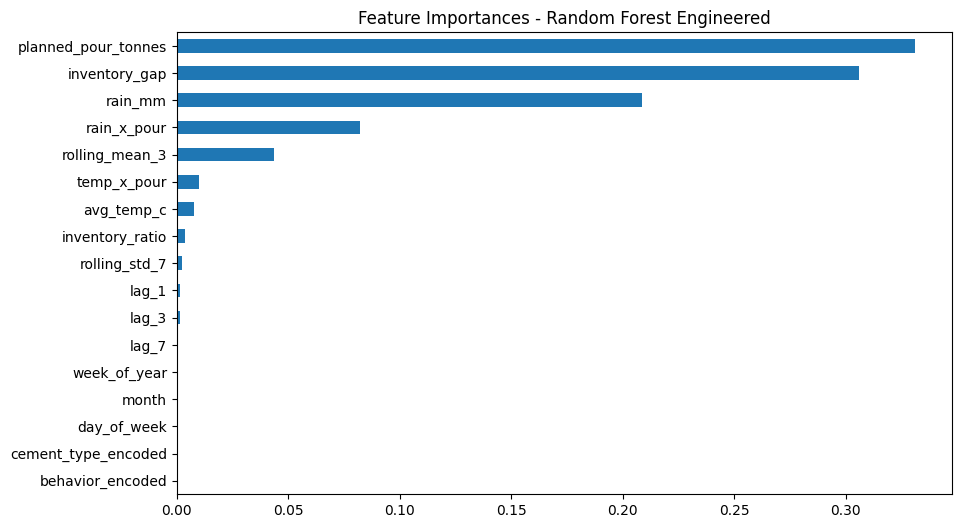

In [529]:
# identify the feature importances
importance = pd.Series(
  rf.feature_importances_,
  index=features
).sort_values()
importance.plot(
  kind='barh',
  figsize=(10, 6),
  title='Feature Importances - Random Forest Engineered'
)

In [530]:
site_df['silo_capacity'].head()

date
2022-01-08    448
2022-01-09    448
2022-01-10    448
2022-01-11    448
2022-01-12    448
Name: silo_capacity, dtype: int64

### Inventory Simulation


In [531]:
# Inventory and Buffer Settings
silo_capacity = site_df['silo_capacity'].iloc[0]
initial_inventory = 0.60 * silo_capacity
reorder_threshold = 0.2 * silo_capacity
target_inventory = 0.8 * silo_capacity
lead_time_days = 2

buffer_rain_threshold = 10  # mm
buffer_increase = 0.1


In [532]:
df_sim = pd.DataFrame({
  'date': X_test.index,
  'forecasted_consumption': rf_forecast,
  'rain_forecast_mm': X_test['rain_mm'].values
})

In [533]:
df_sim.head()

,date,forecasted_consumption,rain_forecast_mm
0,2024-05-28,0.306700,0.69
1,2024-05-29,39.998771,2.36
2,2024-05-30,33.414488,0.99
3,2024-05-31,12.994374,0.67
4,2024-06-01,28.023198,0.11


In [534]:
# simulation loop
df_sim['sim_inventory'] = np.nan
df_sim['reorder_flag'] = False
df_sim['recommended_delivery_date'] = None
df_sim['recommended_delivery_qty'] = 0.0
df_sim['buffer_applied'] = False

In [535]:
# Simulate inventory levels and generate delivery recommendations
inventory = initial_inventory
delivery_queue = {}

# Iterate through the simulation dataframe
for i, row, in df_sim.iterrows():
    today = row['date']

    # Check if there are any deliveries scheduled for today
    if today in delivery_queue:
        inventory += delivery_queue[today]
        inventory = min(inventory, silo_capacity)  
        del delivery_queue[today]
    # Update inventory based on forecasted consumption
    consumption = row['forecasted_consumption']
    inventory -= consumption
    
    df_sim.loc[i, 'sim_inventory'] = inventory

    # Check if inventory is below the reorder threshold
    if inventory < reorder_threshold:
        df_sim.loc[i, 'reorder_flag'] = True
        delivery_date = today + pd.Timedelta(days=lead_time_days)

        # Calculate the delivery quantity needed to reach the target inventory
        delivery_qty = target_inventory - inventory
        if row['rain_forecast_mm'] > buffer_rain_threshold:
            delivery_qty *= (1 + buffer_increase)
            df_sim.loc[i, 'buffer_applied'] = True

        # Ensure that the delivery quantity does not exceed the silo capacity
        delivery_qty = min(delivery_qty, silo_capacity - inventory)
        delivery_queue[delivery_date] = delivery_qty

        # Update the dataframe with the recommended delivery date and quantity
        df_sim.loc[i, 'recommended_delivery_date'] = delivery_date.strftime('%Y-%m-%d')
        df_sim.loc[i, 'recommended_delivery_qty'] = round(delivery_qty, 2)

In [536]:
stockouts = (df_sim['sim_inventory'] < 0).sum()
service_level = 100 * (1 - stockouts / len(df_sim))
num_deliveries = (df_sim['reorder_flag']).sum()

In [537]:
print(f'Service Level: {service_level:.2f}%')
print(f'stockouts: {stockouts}')
print(f'Number of deliveries: {num_deliveries}')

Service Level: 98.62%
stockouts: 3
Number of deliveries: 28


In [538]:
df_sim.columns

Index(['date', 'forecasted_consumption', 'rain_forecast_mm', 'sim_inventory',
       'reorder_flag', 'recommended_delivery_date', 'recommended_delivery_qty',
       'buffer_applied'],
      dtype='object')

In [539]:
df_sim.head(20)

,date,forecasted_consumption,rain_forecast_mm,sim_inventory,reorder_flag,recommended_delivery_date,recommended_delivery_qty,buffer_applied
0,2024-05-28,0.306700,0.69,268.493300,False,None,0.00,False
1,2024-05-29,39.998771,2.36,228.494529,False,None,0.00,False
2,2024-05-30,33.414488,0.99,195.080040,False,None,0.00,False
3,2024-05-31,12.994374,0.67,182.085667,False,None,0.00,False
4,2024-06-01,28.023198,0.11,154.062469,False,None,0.00,False
5,2024-06-02,30.341231,1.71,123.721238,False,None,0.00,False
6,2024-06-03,45.173043,2.84,78.548195,True,2024-06-05,279.85,False
7,2024-06-04,23.504425,3.34,55.043770,True,2024-06-06,303.36,False
8,2024-06-05,23.200839,3.96,311.694736,False,None,0.00,False
9,2024-06-06,25.350219,2.60,422.649781,False,None,0.00,False


### Feature Engineering For all sites

In [540]:
# Feature engineering for cement consumption prediction
from sklearn.metrics import mean_squared_error

# encode categorical columns
df['behavior_encoded'] = df['behavior'].astype('category').cat.codes
df['cement_type_encoded'] = df['cement_type'].astype('category').cat.codes

all_site_metrics = []
all_site_predictions = []
all_feature_importances = []

features = [
    'planned_pour_tonnes', 'rain_mm', 'avg_temp_c',
    'lag_1', 'lag_3', 'lag_7', 'rolling_mean_3', 'rolling_std_7',
    'day_of_week', 'week_of_year', 'month', 'rain_x_pour', 'temp_x_pour',
    'behavior_encoded', 'cement_type_encoded', 'inventory_gap',
    'inventory_ratio'
]

for site_id in df['site_id'].unique():
  try:
    site_df = df[df['site_id'] == site_id].copy()
    site_df = site_df.set_index('date')
    site_df = site_df.sort_index()

    # lag features
    site_df['lag_1'] = site_df['consumed_tonnes'].shift(1)
    site_df['lag_3'] = site_df['consumed_tonnes'].shift(3)
    site_df['lag_7'] = site_df['consumed_tonnes'].shift(7)

    # rolling mean and std features
    site_df['rolling_mean_3'] = site_df['consumed_tonnes'].rolling(3).mean()
    site_df['rolling_std_7'] = site_df['consumed_tonnes'].rolling(7).std()

    # date features
    site_df['day_of_week'] = site_df.index.dayofweek
    site_df['week_of_year'] = site_df.index.isocalendar().week.astype(int)
    site_df['month'] = site_df.index.month

    # interaction features
    site_df['rain_x_pour'] = site_df['rain_mm'] * site_df['planned_pour_tonnes']
    site_df['temp_x_pour'] = site_df['avg_temp_c'] * site_df['planned_pour_tonnes']

    # inventory features
    site_df['inventory_gap'] = (
      site_df['opening_inventory_tonnes'] 
      + site_df['deliveries_tonnes']
      - site_df['planned_pour_tonnes']
    )

    site_df['inventory_ratio'] = np.where(
      site_df['silo_capacity'] > 0,
      site_df['opening_inventory_tonnes'] / site_df['silo_capacity'],
      np.nan
    )

    site_df = site_df.dropna()

    if len(site_df) < 20:
      continue  # Skip sites with insufficient data

    X = site_df[features]
    y = site_df['consumed_tonnes']

    split_index = int(len(site_df) * 0.8)

    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    rf = RandomForestRegressor(
      n_estimators=100,
      max_depth=10,
      random_state=42
    )

    rf.fit(X_train, y_train)

    rf_forecast = rf.predict(X_test)

    mask = y_test != 0

    mape = np.mean(
      np.abs((y_test[mask] - rf_forecast[mask]) / y_test[mask])
    ) * 100

    rmse = np.sqrt(
      mean_squared_error(y_test[mask], rf_forecast[mask])
    )

    all_site_metrics.append({
      'site_id': site_id,
      'mape': round(mape, 2),
      'rmse': round(rmse, 2)
    })

    site_predictions = pd.DataFrame({
      'site_id': site_id,
      'date': y_test.index,
      'actual_consumed_tonnes': y_test.values,
      'forecasted_consumed_tonnes': rf_forecast
    })

    all_site_predictions.append(site_predictions)

    for feature, importance in zip(features, rf.feature_importances_):
      all_feature_importances.append({
        'site_id': site_id,
        'feature': feature,
        'importance': importance
      })

  except Exception as e:
    print(f"Error processing site {site_id}: {e}")



In [541]:
engineered_metrics_df = pd.DataFrame(all_site_metrics)

engineered_predictions_df = pd.concat(
  all_site_predictions,
  ignore_index=True
)

engineered_feature_importances_df = pd.DataFrame(all_feature_importances)

overall_mape = engineered_metrics_df['mape'].mean()
overall_rmse = engineered_metrics_df['rmse'].mean()

overall_row = pd.DataFrame([{
  'site_id': 'Overall',
  'mape': round(overall_mape, 2),
  'rmse': round(overall_rmse, 2)
}])

engineered_metrics_df = pd.concat(
  [engineered_metrics_df, overall_row],
  ignore_index=True
)

engineered_metrics_df 

,site_id,mape,rmse
0,SITE_001,4.99,1.82
1,SITE_002,1.26,0.34
2,SITE_003,4.82,2.51
3,SITE_004,1.22,0.26
4,SITE_005,5.67,2.50
5,SITE_006,4.78,2.13
6,SITE_007,4.86,1.83
7,SITE_008,6.40,2.03
8,SITE_009,1.12,0.31
9,SITE_010,6.40,3.99


In [542]:
# overall feature importances
overall_feature_importances_df = (
  engineered_feature_importances_df
  .groupby('feature')['importance']
  .mean()
  .reset_index()
  .sort_values(by='importance', ascending=False)
)

overall_feature_importances_df

,feature,importance
10,planned_pour_tonnes,0.613690
4,inventory_gap,0.158207
11,rain_mm,0.109364
12,rain_x_pour,0.053807
13,rolling_mean_3,0.039535
15,temp_x_pour,0.008591
0,avg_temp_c,0.007841
5,inventory_ratio,0.002834
6,lag_1,0.001987
14,rolling_std_7,0.001834


<Axes: title={'center': 'Feature Importances - Random Forest Engineered'}, ylabel='feature'>

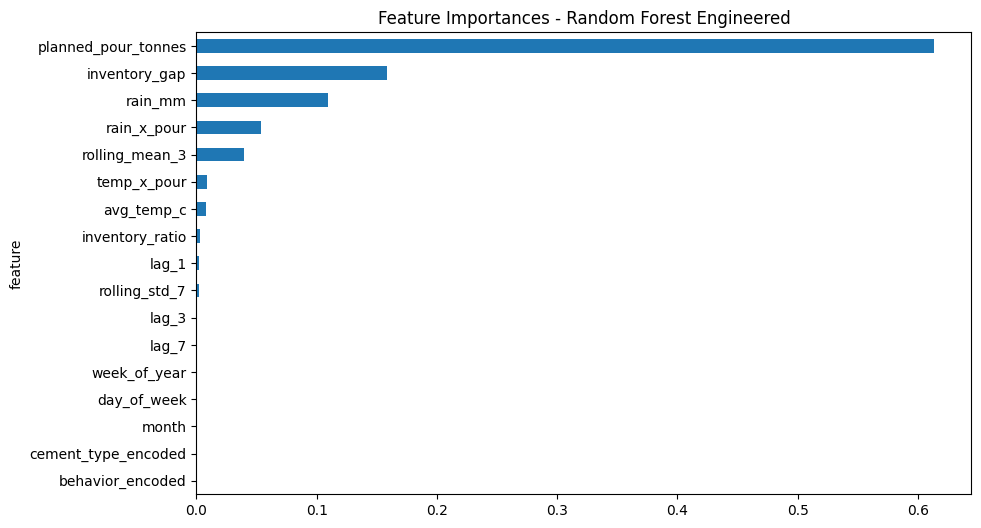

In [543]:
# identify the overall feature importances
importance = (
  engineered_feature_importances_df
  .groupby('feature')['importance']
  .mean()
  .sort_values()
)
importance.plot(
  kind='barh',
  figsize=(10, 6),
  title='Feature Importances - Random Forest Engineered'
)

In [544]:
# inventory simulation for all sites
all_inventory_simulations = []

lead_time_days = 2
buffer_rain_threshold = 10  # mm
buffer_increase = 0.1

for site_id in engineered_predictions_df['site_id'].unique():
  try:
    pred_df = engineered_predictions_df[
      engineered_predictions_df['site_id'] == site_id
    ].copy()

    pred_df['date'] = pd.to_datetime(pred_df['date'])
    pred_df = pred_df.sort_values(by='date')

    site_info = df[df['site_id'] == site_id].copy()
    site_info['date'] = pd.to_datetime(site_info['date'])

    pred_df = pred_df.merge(
      site_info[[
        'date',
        'silo_capacity',
        'opening_inventory_tonnes',
        'rain_mm'
      ]],
      on='date',
      how='left'
    )

    silo_capacity = pred_df['silo_capacity'].iloc[0]
    initial_inventory = 0.60 * silo_capacity

    reorder_threshold = 0.2 * silo_capacity
    target_inventory = 0.8 * silo_capacity

    pred_df['sim_inventory'] = np.nan
    pred_df['reorder_flag'] = False
    pred_df['recommended_delivery_date'] = None
    pred_df['recommended_delivery_qty'] = 0.0
    pred_df['buffer_applied'] = False

    inventory = initial_inventory
    delivery_queue = {}

    for i, row in pred_df.iterrows():
        today = row['date']

        if today in delivery_queue:
            inventory += delivery_queue[today]
            inventory = min(inventory, silo_capacity)
            del delivery_queue[today]

        consumption = row['forecasted_consumed_tonnes']
        inventory -= consumption

        pred_df.loc[i, 'sim_inventory'] = inventory

        if inventory < reorder_threshold:
            pred_df.loc[i, 'reorder_flag'] = True
            delivery_date = today + pd.Timedelta(days=lead_time_days)

            delivery_qty = target_inventory - inventory
            if row['rain_mm'] > buffer_rain_threshold:
                delivery_qty *= (1 + buffer_increase)
                pred_df.loc[i, 'buffer_applied'] = True

            delivery_qty = min(delivery_qty, silo_capacity - inventory)
            delivery_queue[delivery_date] = delivery_qty

            pred_df.loc[i, 'recommended_delivery_date'] = delivery_date.strftime('%Y-%m-%d')
            pred_df.loc[i, 'recommended_delivery_qty'] = round(delivery_qty, 2)

    all_inventory_simulations.append(pred_df)

  except Exception as e:
    print(f"Error processing inventory simulation for site {site_id}: {e}")

inventory_simulations_df = pd.concat(
  all_inventory_simulations,
  ignore_index=True
)

inventory_simulations_df.head()

# print simulation for site_id = 'SITE_002'
display(inventory_simulations_df[inventory_simulations_df['site_id'] == 'SITE_004'])

,site_id,date,actual_consumed_tonnes,forecasted_consumed_tonnes,silo_capacity,opening_inventory_tonnes,rain_mm,sim_inventory,reorder_flag,recommended_delivery_date,recommended_delivery_qty,buffer_applied
654,SITE_004,2024-05-28,6.32,6.345489,472,16370.13,4.03,276.854511,False,None,0.00,False
655,SITE_004,2024-05-29,17.10,17.092157,472,16389.42,8.55,259.762354,False,None,0.00,False
656,SITE_004,2024-05-30,8.26,8.266965,472,16393.93,17.38,251.495389,False,None,0.00,False
657,SITE_004,2024-05-31,9.51,9.492931,472,16424.24,8.75,242.002458,False,None,0.00,False
658,SITE_004,2024-06-01,8.02,8.051233,472,16439.59,19.89,233.951225,False,None,0.00,False
...,...,...,...,...,...,...,...,...,...,...,...,...
867,SITE_004,2024-12-27,5.33,5.331592,472,20449.84,7.35,73.312713,True,2024-12-29,304.29,False
868,SITE_004,2024-12-28,5.85,5.814753,472,20456.81,1.94,366.453655,False,None,0.00,False
869,SITE_004,2024-12-29,12.72,12.840000,472,20470.50,7.12,459.160000,False,None,0.00,False
870,SITE_004,2024-12-30,12.44,12.451812,472,20477.27,1.57,446.708188,False,None,0.00,False


In [546]:
# stockouts and service level, number of deliveries calculation for all sites
site_metrics = []
for site_id in inventory_simulations_df['site_id'].unique():
    site_df = inventory_simulations_df[inventory_simulations_df['site_id'] == site_id]
    stockouts = (site_df['sim_inventory'] < 0).sum()
    service_level = 100 * (1 - stockouts / len(site_df))
    num_deliveries = (site_df['reorder_flag']).sum()

    site_metrics.append({
        'site_id': site_id,
        'stockouts': stockouts,
        'service_level': round(service_level, 2),
        'num_deliveries': num_deliveries
    })
site_metrics_df = pd.DataFrame(site_metrics)
display(site_metrics_df)

,site_id,stockouts,service_level,num_deliveries
0,SITE_001,3,98.62,28
1,SITE_002,0,100.00,20
2,SITE_003,3,98.62,39
3,SITE_004,0,100.00,12
4,SITE_005,13,94.04,50
5,SITE_006,0,100.00,26
6,SITE_007,0,100.00,28
7,SITE_008,11,94.95,44
8,SITE_009,0,100.00,16
9,SITE_010,24,88.99,65
